# ERA5 Weather reanalysis - data extraction 

This code was written by Tam Pletzer and modified by Rose Foster-Dyer 


Emperor penguin colony counts from SAR imagery require converting colony **area** (m²) into **number of individuals**. This requires knowledge of the colony **density** (penguins/m²), which varies continuously with weather — penguins huddle tightly in cold, windy, dark conditions and spread out in warm, calm, bright conditions.

Winterl et al. (2024) developed a **windchill model** that predicts colony density from four meteorological variables:
- Air temperature (K)
- Wind speed (m/s)
- Solar radiation (W/m²)
- Relative humidity (%)

To run these analysis, we requested ERA5 weather reanalysis data from here:  https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=download

We requested: 
- '10m_u_component_of_wind', 
- '10m_v_component_of_wind', (combined with the above, you get windspeed)
- "2m_temperature", (in kelvin)
- 'total_sky_direct_solar_radiation_at_surface', (for solar radiation - but as winter obs, most values are 0)
- '2m_dewpoint_temperature (for calculating humidity, when combined with temperature and pressure)
- 'surface_pressure' (downloaded but not used for humidity calculation)

Our data spanned:
-  -60 to -80 latitude  (between 60 and 80 degrees south, where all emperor penguin colonies are located) 
- -180 to +180 longitude (entire circumpolar coastline, where all colonies are found)
- March-September, every day, every hour time stamp. 

# This was the first step of the analysis

We needed to run this for each of the different data files, and the output was then saved into the SAR observation csv files and analysed in the density model. 

## This analysis has been done and the provided datasets already include the extracted data put into the datafiles. 

This shows you how we extracted each weather covariates from the grib file downloaded from ERA5.

In [1]:
#Dependencies: xarray, cfgrib, pandas, numpy, jupyter, matplotlib

import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cfgrib

Open the file. Need to process different variables seperately because cdir, ssr and ssrc are every 12 hours but have a "steps" dimension for the hourly data. The engine cfgrib is for opening grib files, if not it assumes NetCDF.

In [2]:
INPUTPATH = "/mnt/c/Users/rfo37/OneDrive - University of Canterbury/PostDoc/ERA5/Final ERA5 data/"
ds_1h = xr.open_dataset('/mnt/d/ERA5/464928681b92ffdd0f94bc0f9c39eccd.grib', engine='cfgrib') #telling it to go to drive d, external drive where ive put era5 data 


#It is large so it takes a while
#redoing for population estimate VHR - spring time ERA5 data:
#ds_1h = xr.open_dataset('/mnt/d/ERA5/bbfd44a89da5a068c136d740698fc6c5.grib', engine='cfgrib') #telling it to go to drive d, external drive where ive put era5 data 


skipping variable: paramId==228021 shortName='fdir'
Traceback (most recent call last):
  File "/home/rfo37/miniconda3/envs/era5_env/lib/python3.14/site-packages/cfgrib/dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
    ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/rfo37/miniconda3/envs/era5_env/lib/python3.14/site-packages/cfgrib/dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
    ...<2 lines>...
    )
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([1711929600, 1711933200, 1711936800, ..., 1759266000, 1759269600,
       1759273200], shape=(8784,))) new_value=Variable(dimensions=('time',), data=array([1711908000, 1711951200, 1711994400, 1712037600, 1712080800,
       1712124000, 1712167200, 1712210400, 1712253600, 1712296800,
       1712340000, 1712383200, 1712426400, 1712469600, 1712512800,
       1712556000, 1712599200, 1712642400, 1712685

In [3]:
#Used to show which variables and dates are included in the grib file (useful when we have multiple)

import cfgrib

datasets = cfgrib.open_datasets('/mnt/d/ERA5/464928681b92ffdd0f94bc0f9c39eccd.grib')

for i, ds in enumerate(datasets):
    print(f"\nDataset {i}:")
    print(f"  Variables: {list(ds.data_vars)}")
    print(f"  Time range: {str(ds.time.values.min())} to {str(ds.time.values.max())}")
    print(f"  Dimensions: {dict(ds.dims)}")


Dataset 0:
  Variables: ['sp', 'u10', 'v10', 't2m', 'd2m']
  Time range: 2024-04-01T00:00:00.000000000 to 2025-09-30T23:00:00.000000000
  Dimensions: {'time': 8784, 'latitude': 81, 'longitude': 1440}

Dataset 1:
  Variables: ['fdir']
  Time range: 2024-03-31T18:00:00.000000000 to 2025-09-30T18:00:00.000000000
  Dimensions: {'time': 734, 'step': 12, 'latitude': 81, 'longitude': 1440}


/home/rfo37/miniconda3/envs/era5_env/lib/python3.14/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/home/rfo37/miniconda3/envs/era5_env/lib/python3.14/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kw

Open csv file with the latitudes and longitudes

In [4]:
#We just modify which data file is called here (and the correct ERA5 datafile downloaded for the correct time)

#open the csv of lats and lons
locs = pd.read_csv('/mnt/d/ERA5/sar_huddles_20250502_ERA5_v3_grouped_noera5yet.csv', index_col=0) #Michelle's 2024 data 

#w Wintertime SAR imagery 2025
#locs = pd.read_csv('/mnt/d/ERA5/SARdatav2_ERA5_v7_cleaned.csv', index_col=0)

#Springtime VHR data:
#locs = pd.read_csv('/mnt/d/ERA5/VHR_RossSea2025_area-data.csv', index_col=0)
print(locs) 


                                             image_id         area        lat  \
colony                                                                          
Atka Bay         2024-03-22-20-13-47_UMBRA-06_GEC.tif     0.000000 -70.619776   
Atka Bay         2024-04-12-20-38-35_UMBRA-06_GEC.tif  1560.178706 -70.619776   
Atka Bay         2024-04-24-00-04-46_UMBRA-04_GEC.tif  2551.889450 -70.622147   
Atka Bay         2024-04-29-23-56-56_UMBRA-07_GEC.tif   739.831055 -70.615370   
Atka Bay         2024-05-09-00-18-11_UMBRA-05_GEC.tif  3273.181245 -70.620259   
...                                               ...          ...        ...   
Franklin Island  2024-05-17-21-03-38_UMBRA-05_GEC.tif   990.336490 -76.177269   
Franklin Island  2024-05-24-21-23-43_UMBRA-05_GEC.tif  1170.398216 -76.177902   
Franklin Island  2024-06-07-18-46-38_UMBRA-05_GEC.tif  1047.064489 -76.177457   
Franklin Island  2024-06-24-20-55-35_UMBRA-04_GEC.tif   684.656560 -76.177269   
Franklin Island  2024-08-09-

## For Michelle's data we had to extract the correct time stamps from within the file name before we could extract the data



In [5]:

#Need to extract the date time from the 'image_id' column: 
#This one is different for the VHR optical file - not running, see chunk below
import re
import pandas as pd
from datetime import datetime


# Extract datetime from filename using regex
#Building function:
def extract_datetime(filename):
    match = re.search(r"(\d{4}-\d{2}-\d{2}-\d{2}-\d{2}-\d{2})", filename)
    if match:
        return datetime.strptime(match.group(1), "%Y-%m-%d-%H-%M-%S")
    return None

# Apply to the filename column
locs["date_time"] = locs["image_id"].apply(extract_datetime) #called "image" in Michelle's - image_ID in ours CHANGED SO BOTH ARE IMAGE_ID

# Split into separate date and time columns
locs["date"] = locs["date_time"].dt.date
locs["time"] = locs["date_time"].dt.time
locs["year"] = locs["date_time"].dt.year
locs["month"] = locs["date_time"].dt.month
locs["day"] = locs["date_time"].dt.day
locs["doy"] = locs["date_time"].dt.day_of_year  # day of year 1-366
locs["date_utc"] = locs["date_time"].dt.strftime("%Y-%m-%d")          # clean date string e.g. '2025-04-24'
locs["time_utc"] = locs["date_time"].dt.strftime("%H:%M:%S UTC")       # time with UTC label e.g. '19:46:14 UTC'
locs["ts"] = locs["date_time"].dt.strftime("%Y-%m-%d %H:%M:%S")  # python standard format


#locs["lon"] = locs["xcoord"] #required for Michelle's data, not ours 
#locs["lat"] = locs["ycoord"] #required for Michelle's data, not ours 

print(locs[["image_id", "date_time", "date_utc", "time_utc", "ts", "year", "month", "day", "doy"]].head())
#print(locs[["image_id", "date_time", "date", "time", "year", "month", "day", "doy"]].head())

                                      image_id           date_time  \
colony                                                               
Atka Bay  2024-03-22-20-13-47_UMBRA-06_GEC.tif 2024-03-22 20:13:47   
Atka Bay  2024-04-12-20-38-35_UMBRA-06_GEC.tif 2024-04-12 20:38:35   
Atka Bay  2024-04-24-00-04-46_UMBRA-04_GEC.tif 2024-04-24 00:04:46   
Atka Bay  2024-04-29-23-56-56_UMBRA-07_GEC.tif 2024-04-29 23:56:56   
Atka Bay  2024-05-09-00-18-11_UMBRA-05_GEC.tif 2024-05-09 00:18:11   

            date_utc      time_utc                   ts  year  month  day  doy  
colony                                                                          
Atka Bay  2024-03-22  20:13:47 UTC  2024-03-22 20:13:47  2024      3   22   82  
Atka Bay  2024-04-12  20:38:35 UTC  2024-04-12 20:38:35  2024      4   12  103  
Atka Bay  2024-04-24  00:04:46 UTC  2024-04-24 00:04:46  2024      4   24  115  
Atka Bay  2024-04-29  23:56:56 UTC  2024-04-29 23:56:56  2024      4   29  120  
Atka Bay  2024-05-09  0

In [6]:
import pandas as pd

#locs = pd.read_csv('/path/to/VHR_RossSea2025_area-data.csv')
locs.columns = locs.columns.str.strip()  # remove any whitespace from column names

# Parse datetime from existing date and time_UTC columns
locs["date_time"] = pd.to_datetime(locs["date_utc"] + ' ' + locs["time_utc"], dayfirst=True)

# Split into separate columns
locs["date_utc"] = locs["date_time"].dt.strftime("%Y-%m-%d")
locs["time_utc"] = locs["date_time"].dt.strftime("%H:%M:%S UTC")
locs["ts"] = locs["date_time"].dt.strftime("%Y-%m-%d %H:%M:%S")
locs["year"] = locs["date_time"].dt.year
locs["month"] = locs["date_time"].dt.month
locs["day"] = locs["date_time"].dt.day
locs["doy"] = locs["date_time"].dt.day_of_year

print(locs[["image_id", "date_time", "date_utc", "time_utc", "ts", "year", "month", "day", "doy"]].head())

                                      image_id                 date_time  \
colony                                                                     
Atka Bay  2024-03-22-20-13-47_UMBRA-06_GEC.tif 2024-03-22 20:13:47+00:00   
Atka Bay  2024-04-12-20-38-35_UMBRA-06_GEC.tif 2024-04-12 20:38:35+00:00   
Atka Bay  2024-04-24-00-04-46_UMBRA-04_GEC.tif 2024-04-24 00:04:46+00:00   
Atka Bay  2024-04-29-23-56-56_UMBRA-07_GEC.tif 2024-04-29 23:56:56+00:00   
Atka Bay  2024-05-09-00-18-11_UMBRA-05_GEC.tif 2024-05-09 00:18:11+00:00   

            date_utc      time_utc                   ts  year  month  day  doy  
colony                                                                          
Atka Bay  2024-03-22  20:13:47 UTC  2024-03-22 20:13:47  2024      3   22   82  
Atka Bay  2024-04-12  20:38:35 UTC  2024-04-12 20:38:35  2024      4   12  103  
Atka Bay  2024-04-24  00:04:46 UTC  2024-04-24 00:04:46  2024      4   24  115  
Atka Bay  2024-04-29  23:56:56 UTC  2024-04-29 23:56:56  2024 

/tmp/ipykernel_6807/173272460.py:7: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S %Z format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  locs["date_time"] = pd.to_datetime(locs["date_utc"] + ' ' + locs["time_utc"], dayfirst=True)


## Formulas to calculate the saturation pressure with respect to water and ice

In [7]:
def e_sat_water(T):
    """T in Kelvin, returns hPa"""
    Tc = T - 273.15
    return 6.1078 * np.exp(17.27 * Tc / (Tc + 237.3))

# Saturation vapor pressure over ice
def e_sat_ice(T):
    """T in Kelvin, returns hPa"""
    Tc = T - 273.15
    return 6.1078 * np.exp(21.875 * Tc / (Tc + 265.5))

## Loop through the csv file rows and calculate windspeed, relative humidity and add ERA5 data for the corresponding date, latitude and longitude to new columns

In [8]:
#Sorting timezone bug: 
locs['date_time'] = pd.to_datetime(locs['date_time']).dt.tz_convert('UTC').dt.tz_localize(None)

#Step 1: 1h time stamp variables
#Previous code is creating the same value of every row, regardless of location, date or time, so we need to fix it: 
locs['windspeed'] = np.nan
locs['t2m'] = np.nan
locs['d2m'] = np.nan
locs['rh'] = np.nan
locs['rh_water'] = np.nan
locs['rh_ice'] = np.nan
errors = [] 


windspeed_col = locs.columns.get_loc('windspeed')
t2m_col = locs.columns.get_loc('t2m')
d2m_col = locs.columns.get_loc('d2m')
rh_col = locs.columns.get_loc('rh')
rh_water_col = locs.columns.get_loc('rh_water')
rh_ice_col = locs.columns.get_loc('rh_ice')

for i, (index, row) in enumerate(locs.iterrows()):
    lat = row['lat']
    lon = row['lon']
    time_data = row['date_time']

    try:
        data_pt = ds_1h.sel(time=pd.Timestamp(time_data), latitude=lat, longitude=lon, method='nearest')
    except Exception:
        try:
            t = pd.Timestamp(str(locs.iloc[i]['date']) + ' ' + str(locs.iloc[i]['time']))
            data_pt = ds_1h.sel(time=t, latitude=lat, longitude=lon, method='nearest')
        except Exception:
            errors.append(i)
            continue

    e_actual = e_sat_water(float(data_pt['d2m']))
    rh_water = 100 * e_actual / e_sat_water(float(data_pt['t2m']))
    rh_ice = 100 * e_actual / e_sat_ice(float(data_pt['t2m']))

    locs.iloc[i, windspeed_col] = float(np.sqrt(data_pt['u10']**2 + data_pt['v10']**2))
    locs.iloc[i, t2m_col] = float(data_pt['t2m'])
    locs.iloc[i, d2m_col] = float(data_pt['d2m'])
    locs.iloc[i, rh_water_col] = float(rh_water)
    locs.iloc[i, rh_ice_col] = float(rh_ice)
    locs.iloc[i, rh_col] = float(rh_ice) if float(data_pt['t2m']) <= 273.15 else float(rh_water)

print(f"Skipped {len(errors)} rows: {errors}")



Skipped 0 rows: []


In [9]:
print(locs.head())
#save csv 
locs.to_csv('/mnt/d/ERA5/sar_huddles_20250502_ERA5_v3_grouped_era5added.csv', index=False) #Saving the MLR dataset w new images added

#print(locs.head())
#save csv 
#locs.to_csv('/mnt/d/ERA5/VHR_RossSea2025_area-data.csv', index=False)


                                      image_id         area        lat  \
colony                                                                   
Atka Bay  2024-03-22-20-13-47_UMBRA-06_GEC.tif     0.000000 -70.619776   
Atka Bay  2024-04-12-20-38-35_UMBRA-06_GEC.tif  1560.178706 -70.619776   
Atka Bay  2024-04-24-00-04-46_UMBRA-04_GEC.tif  2551.889450 -70.622147   
Atka Bay  2024-04-29-23-56-56_UMBRA-07_GEC.tif   739.831055 -70.615370   
Atka Bay  2024-05-09-00-18-11_UMBRA-05_GEC.tif  3273.181245 -70.620259   

               lon          datetime        date      time b_pres  \
colony                                                              
Atka Bay -8.155337  22/03/2024 20:13  2024-03-22  20:13:47     no   
Atka Bay -8.155337  12/04/2024 20:38  2024-04-12  20:38:35    yes   
Atka Bay -8.159169   24/04/2024 0:04  2024-04-24  00:04:46    yes   
Atka Bay -8.157442  29/04/2024 23:56  2024-04-29  23:56:56    yes   
Atka Bay -8.156834    9/05/2024 0:18  2024-05-09  00:18:11    yes  

## To add shortwave radiation to the dataset:

ds = xr.open_dataset(filename, engine='cfgrib') #try opening the file, filename needs quotes around it

Then run the following block of code:
replace var_name with the variable name in quotes. If you require a mean, you may need to calculate temporal mean first

In [10]:
# Step 2: ds_sw_fixed setup + fdir loop
#NEW SHORTWAVE CODE:
#Wintertime ERA5 Data 2024 and 2025
ds_sw = xr.open_dataset('/mnt/d/ERA5/464928681b92ffdd0f94bc0f9c39eccd.grib', engine='cfgrib', 
                        backend_kwargs={'filter_by_keys': {'shortName': ['fdir']}})

#These data are for springtime VHR analysis 2024 and 2025
#ds_sw = xr.open_dataset('/mnt/d/ERA5/bbfd44a89da5a068c136d740698fc6c5.grib', engine='cfgrib', 
#                        backend_kwargs={'filter_by_keys': {'shortName': ['fdir']}})

In [11]:
# Step 2: ds_sw_fixed setup + fdir loop
converted = []
for var in ds_sw.data_vars:
    da = ds_sw[var]
    times = da.time.values
    steps = da.step.values
    valid_times = pd.DatetimeIndex([t + s for t in times for s in steps])
    
    da_hourly = xr.DataArray(
        da.values.reshape(-1, *da.shape[2:]),
        dims=['time', 'latitude', 'longitude'],
        coords={
            'time': valid_times,
            'latitude': da.latitude,
            'longitude': da.longitude,
        },
        name=var,
        attrs=da.attrs,
    )
    converted.append(da_hourly.sortby('time'))

ds_sw_fixed = xr.merge(converted)
ds = ds_sw_fixed
errors = []
locs['fdir'] = 0.0

for i, (index, row) in enumerate(locs.iterrows()):
    lat = row['lat']
    lon = row['lon']
    time_data = row['date_time']

    try:
        t = pd.to_datetime(time_data).ceil('h')
        data_pt = ds.sel(time=t, latitude=lat, longitude=lon, method='nearest')
        locs.iloc[i, locs.columns.get_loc('fdir')] = float(data_pt['fdir']) / 3600
    except Exception as e:
        locs.iloc[i, locs.columns.get_loc('fdir')] = 0.0
        errors.append(index)
        continue

print(f"Skipped {len(errors)} rows: {errors}")

# Step 3: save everything together
#locs.to_csv('/mnt/d/ERA5/VHR_RossSea2025_area-data_v1.csv', index=False)
locs.to_csv('/mnt/d/ERA5/sar_huddles_20250502_ERA5_v3_grouped_era5added.csv', index=False)

#not blank and makes sense, can skip the rest of the code

Skipped 0 rows: []


## Blank solar radiation obs 

We found that our solar radiation data were 0s, so I wanted to double check that it was correct or if something needed to be fixed

In [ ]:


# Check fdir in the raw grib dataset
matches = []

for index, row in locs.iterrows():
    lat = row['lat']
    lon = row['lon']
    t = pd.to_datetime(row['date_time']).ceil('h')
    
    val = ds['fdir'].sel(time=t, latitude=lat, longitude=lon, method='nearest')
    fdir_val = float(val)
    
    if fdir_val > 0:
        matches.append({
            'index': index,
            'lat': lat,
            'lon': lon,
            'datetime': row['date_time'],
            'time_matched': val.time.values,
            'fdir': fdir_val / 3600
        })

print(f"Non-zero fdir matches: {len(matches)} / {len(locs)}")
if matches:
    matches_df = pd.DataFrame(matches).dropna(subset=['lat', 'lon'])
    if len(matches_df) > 0:
        print(matches_df)
        march_matches = matches_df[pd.to_datetime(matches_df['datetime']).dt.month == 3]
        if len(march_matches) > 0:
            print(f"Note: {len(march_matches)} non-zero fdir value(s) were from March and excluded as birds are not visible in this month.")
    else:
        print("All valid fdir values are 0 - this is due to polar night and not an error.")
else:
    print("All fdir values are 0 - this is due to polar night and not an error.")

Non-zero fdir matches: 31 / 277
    index        lat         lon            datetime        time_matched  \
0      58 -65.281300  103.186400 2025-08-20 02:10:01 2025-08-20 03:00:00   
1      64 -66.539100   93.033000 2025-04-25 02:36:42 2025-04-25 03:00:00   
2      68 -66.539100   93.033000 2025-08-27 02:39:05 2025-08-27 03:00:00   
3      72 -66.067452   86.496904 2025-04-28 02:44:30 2025-04-28 03:00:00   
4      76 -66.067452   86.496904 2025-07-20 04:32:25 2025-07-20 05:00:00   
5      77 -66.067452   86.496904 2025-08-22 04:05:14 2025-08-22 05:00:00   
6      93 -70.725200  166.487000 2025-04-24 22:47:58 2025-04-24 23:00:00   
7     104 -66.260860  129.981070 2025-08-21 00:21:54 2025-08-21 01:00:00   
8     110 -66.088900  121.162400 2025-08-22 00:59:06 2025-08-22 01:00:00   
9     111 -66.108900  121.257000 2025-08-22 00:58:26 2025-08-22 01:00:00   
10    120 -65.840500  110.143900 2025-08-22 01:51:15 2025-08-22 02:00:00   
11    125 -67.887000   69.696000 2025-08-22 04:06:53 202

/tmp/ipykernel_1873/3335633726.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')


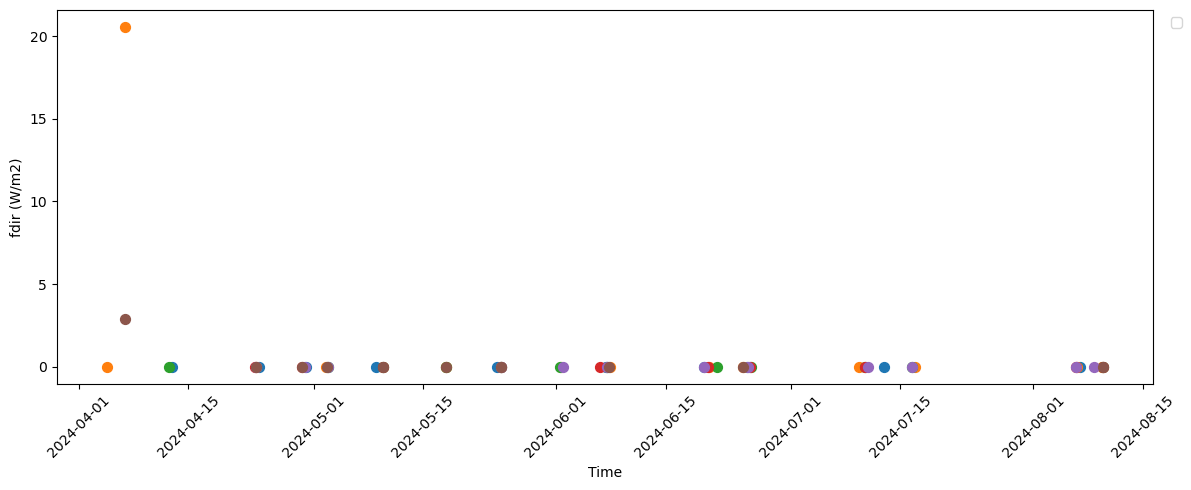

In [11]:
#to check plot:
df = locs[['date_time', 'fdir']].copy()
df['date_time'] = pd.to_datetime(df['date_time'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['date_time'])
df = df.sort_values('date_time')

fig, ax = plt.subplots(figsize=(12, 5))

for site, group in df.groupby(df.index):
    ax.scatter(group['date_time'], group['fdir'], s=50)
 
ax.set_xlabel('Time')
ax.set_ylabel('fdir (W/m2)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1539/4174471799.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


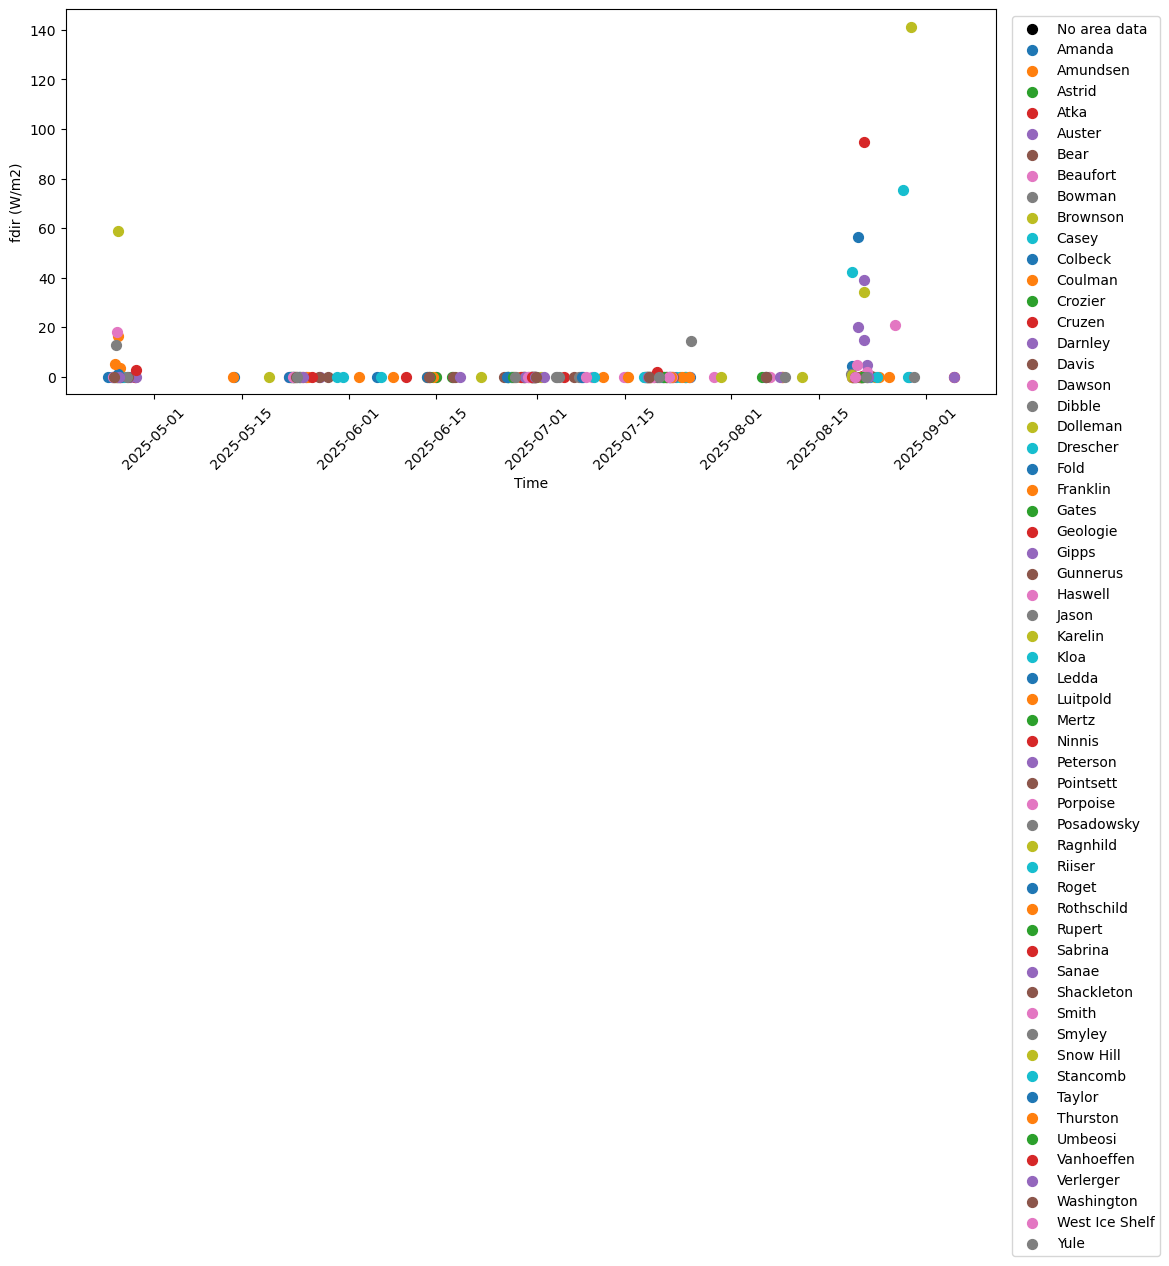

In [21]:
df = locs.reset_index()[['date_time', 'fdir', 'colony_name', 'area_m2']].copy()

fig, ax = plt.subplots(figsize=(12, 5))

# Split by whether area is 0 - to exclude locations that were too early to see birds, but had some sunlight
df_valid = df[df['area_m2'] != 0]
df_zero = df[df['area_m2'] == 0]

# Plot zero area rows in grey
ax.scatter(df_zero['date_time'], df_zero['fdir'], s=50, color='black', label='No area data', zorder=1)


# Plot valid rows by colony
for site, group in df_valid.groupby('colony_name'):
    ax.scatter(group['date_time'], group['fdir'], s=50, label=site, zorder=2)

ax.set_xlabel('Time')
ax.set_ylabel('fdir (W/m2)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# These final steps are unneccesary for our data

We already have one value per image - not per huddle

The following steps were what we had to do to combine all the individual huddle data from Michelle's 2024 dataset into one total observation per colony per image. 

These steps have already been done and do not need to be run again. 

In [ ]:
#OK its all zeros - that is fine 
#Now we need to combine the values, so we have one area estimate per image per location rather than by huddle 
#as the locations are for each huddle, we have some small variation in the weather values - so we should find the average of all them, sum the areas and report one value per image id

#I am now using the dataset where the huddles have been combined so these steps are also uneccesaary for the 2024 data - but good to know what we did. 
import pandas as pd

# Parse the filename to extract components
filename = "sar_huddles_20250502_ERA5_v3"
parts = filename.split('_')
# parts = ['sar', 'huddles', '20250502', 'ERA5']

# Load your dataframe (however you're loading it)
locs = pd.read_csv('/mnt/d/ERA5/sar_huddles_20250502_ERA5_v3.csv', index_col=0)


In [26]:
locs = locs.reset_index()
print(locs.columns.tolist())

['colony', 'image', 'area', 'xcoord', 'ycoord', 'b_pres', 'datetime', 'date', 'time', 'lon', 'lat', 'windspeed', 't2m', 'd2m', 'rh', 'rh_water', 'rh_ice', 'fdir']


In [27]:
locs_grouped = (
    locs.reset_index()
    .groupby(['colony', 'image'], as_index=False)
    .agg(
        area=('area', 'sum'),
        lat=('lat', 'mean'),
        lon=('lon', 'mean'),
        windspeed=('windspeed', 'mean'),
        t2m=('t2m', 'mean'),
        d2m=('d2m', 'mean'),
        rh=('rh', 'mean'),
        rh_water=('rh_water', 'mean'),
        rh_ice=('rh_ice', 'mean'),
        fdir=('fdir', 'mean'),
        datetime=('datetime', 'first'),  # same for all rows in an image
        date=('date', 'first'),
        time=('time', 'first'),
        b_pres=('b_pres', 'first'),
    )
)

print(locs_grouped.shape)
print(locs_grouped.head())

locs_grouped.to_csv('/mnt/d/ERA5/sar_huddles_20250502_ERA5_v3_grouped.csv', index=False)

(64, 16)
     colony                                 image         area        lat  \
0  Atka Bay  2024-03-22-20-13-47_UMBRA-06_GEC.tif     0.000000        NaN   
1  Atka Bay  2024-04-12-20-38-35_UMBRA-06_GEC.tif  1560.178706 -70.619776   
2  Atka Bay  2024-04-24-00-04-46_UMBRA-04_GEC.tif  2551.889450 -70.622147   
3  Atka Bay  2024-04-29-23-56-56_UMBRA-07_GEC.tif   739.831055 -70.615370   
4  Atka Bay  2024-05-09-00-18-11_UMBRA-05_GEC.tif  3273.181245 -70.620259   

        lon  windspeed         t2m         d2m         rh   rh_water  \
0       NaN  15.677855  276.165894  270.951202  68.505779  68.505779   
1 -8.155337  17.323147  263.784485  260.215332  82.190954  75.132970   
2 -8.159169  12.835365  258.472261  253.835511  77.882145  67.619548   
3 -8.157442   8.768179  266.075378  264.905182  97.747303  91.307238   
4 -8.156834   4.215097  254.423790  250.533468  85.283186  71.236156   

      rh_ice  fdir             datetime        date      time b_pres  
0  66.550282   NaN  2024